
---

# A股日内做T时序模型设计方案

## 1. 背景与目标
为了进一步降低持仓成本，计划在不改变选股名单的前提下，利用已有底仓进行**日内做T**（Intraday Trading）。

*   **核心目标：** 利用日内波动的均值回归，在合适的时间点卖出再买入（或先买后卖），降低单笔持仓成本。
*   **约束条件：** 
    1. A股T+1制度（利用老仓实现日内T+0）。
    2. 交易成本（印花税 + 佣金 + 滑点）约需 0.15%~0.2% 空间才能盈利。
    3. 每日收盘前必须复原仓位，不影响截面模型的持仓结构。

---

## 2. TWAP 与 VWAP 的“张力”
核心思路是观察 **Price (当前价)**、**VWAP (成交量加权均价)** 与 **TWAP (时间加权均价)** 之间的动态关系。

### 2.1 资金逻辑解读
*   **VWAP** 代表了当日市场成交的**平均成本中心**。
*   **TWAP** 代表了随时间流逝的**线性平衡线**。
*   **二者偏差的意义：**
    *   $VWAP > TWAP$：说明成交量集中在高位，资金在向上攻击或高位换手。
    *   $VWAP < TWAP$：说明成交量集中在低位，市场处于放量阴跌或低位恐慌砸盘。

---

## 3. 建模方案：均值回归时序模型

### 3.1 特征工程 (Features)
我们以 **10:30** 为关键观察点（此时已包含早盘约 40% 的成交量，信号较为稳固）。

| 特征分类 | 特征公式 | 业务含义 |
| :--- | :--- | :--- |
| **价格偏离 ($X_1$)** | `Price / VWAP - 1` | 当前价格相对于今日平均成本的溢价/折价（橡皮筋拉伸程度）。 |
| **能量偏离 ($X_2$)** | `VWAP / TWAP - 1` | 资金成交的价位重心。衡量早盘是“放量拉升”还是“放量砸盘”。 |
| **成交量能 ($X_3$)** | `Vol_now / Vol_avg_5d` | 当前成交量是否异常放大，作为反转的确认信号。 |
| **时间因子 ($X_4$)** | `Time_to_Close` | 离收盘的时间越近，回归 VWAP 的压力越大。 |

### 3.2 标签设计 (Label)
预测目标不再是绝对涨跌，而是**回归空间**。
*   **目标 $Y$：** `(14:50 收盘价 / 10:30 当前价) - 1`
*   **目标说明：** 寻找在 10:30 时刻，哪些股票到收盘时有最大的回升（做正T）或回落（做倒T）空间。

---

## 4. 数值案例推演
假设我们观察两只股票在 **10:30** 的表现：

### 案例 A：超跌回归（正T机会）
*   **10:30 数据：** Price = 9.80, VWAP = 10.00, TWAP = 10.10
*   **计算特征：**
    *   $X_1$ (Price偏离): $9.80 / 10.00 - 1 = -2.0\%$ （价格显著低于成本中心）
    *   $X_2$ (能量偏离): $10.00 / 10.10 - 1 = -1.0\%$ （低位放量砸盘）
*   **模型预测：** 此时“橡皮筋”拉得太紧，下午收盘前价格大概率向 VWAP 回归。
*   **结果：** 14:50 价格回升至 10.05。做T收益 = **+2.5%**（覆盖成本后盈利约 2.3%）。

### 案例 B：超涨回落（倒T机会）
*   **10:30 数据：** Price = 10.50, VWAP = 10.20, TWAP = 10.10
*   **计算特征：**
    *   $X_1$ (Price偏离): $10.50 / 10.20 - 1 = +2.9\%$ （价格远高于成本中心）
    *   $X_2$ (能量偏离): $10.20 / 10.10 - 1 = +1.0\%$ （高位放量换手）
*   **模型预测：** 情绪过热，脱离成本中枢，下午大概率回踩。
*   **结果：** 14:50 价格回落至 10.30。做T收益 = 先卖后买，降低成本约 **1.9%**。

---

## 5. 小市值股票随机测试

### 批量测试特征X1，X2 与 Y 汇总 （同时合成特征Z）
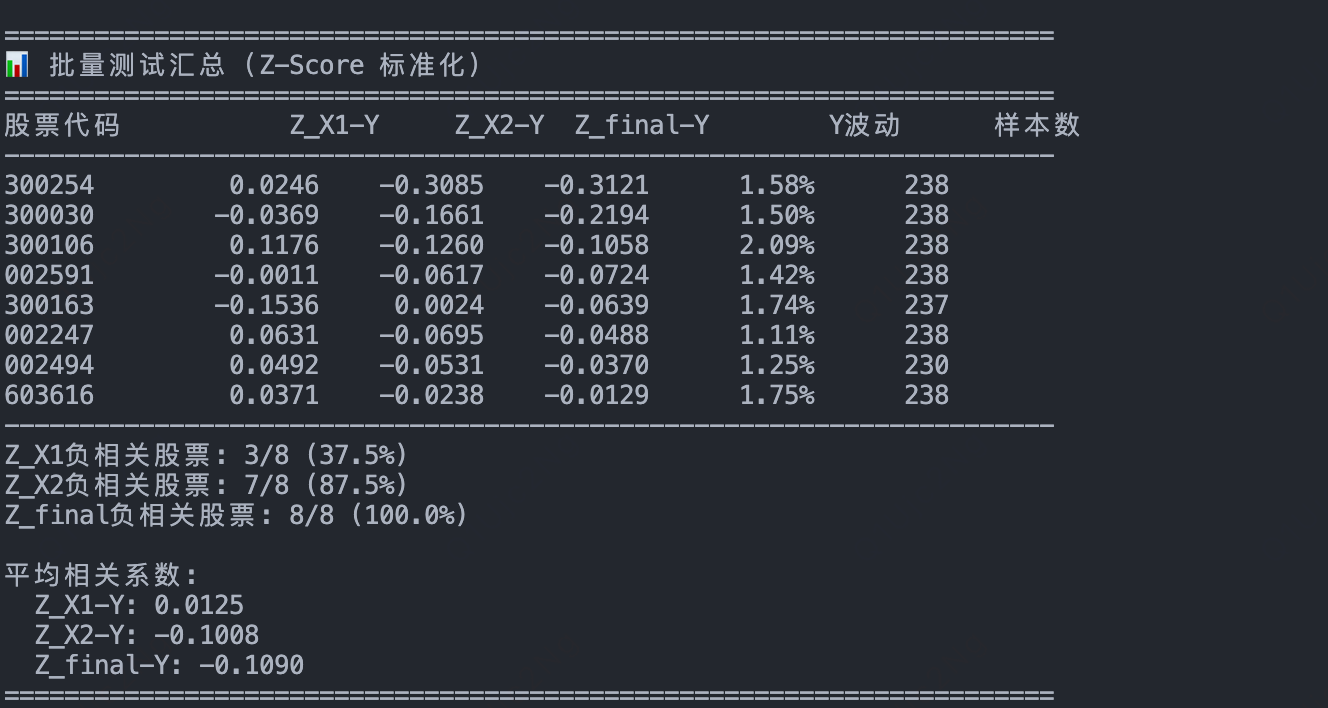

* X1 正负都有，那么X1 到底是一个动量因子还是个反转因子？
* X2 整体保持负相关，说明VWAP/TWAP 的能量偏差具有很强的回归动力

### 共振信号分析
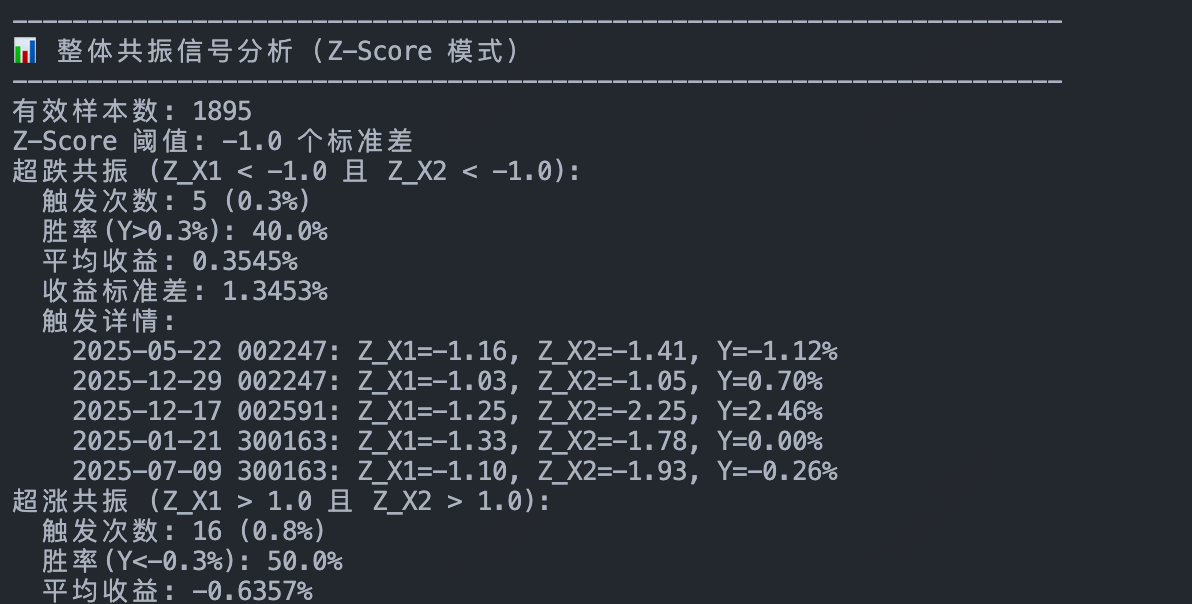

* 超涨共振信号，平均收益-0.6357%，0.63% - 0.2% = 0.43% （每笔净利润）
* 只要共振大于0.2% (印花税+佣金+滑点)，这个策略就可以赚钱
* 毛估一下策略收益：持仓标的数量：100只，100 * 1% = 1个/日，
   单日收益应该是：0.43% * 1% * 1 = 0.43bp, 年化0.43 * 240 = 103BP，年化收益是1.03%
   但如果将持仓标的的数量放大到800-1000只，大概年化收益的增益是8%-10%。

## 6. 中证2000样本 （2025年度测试）

### 批量测试特征X1，X2 与 Y 汇总 （同时合成特征Z）
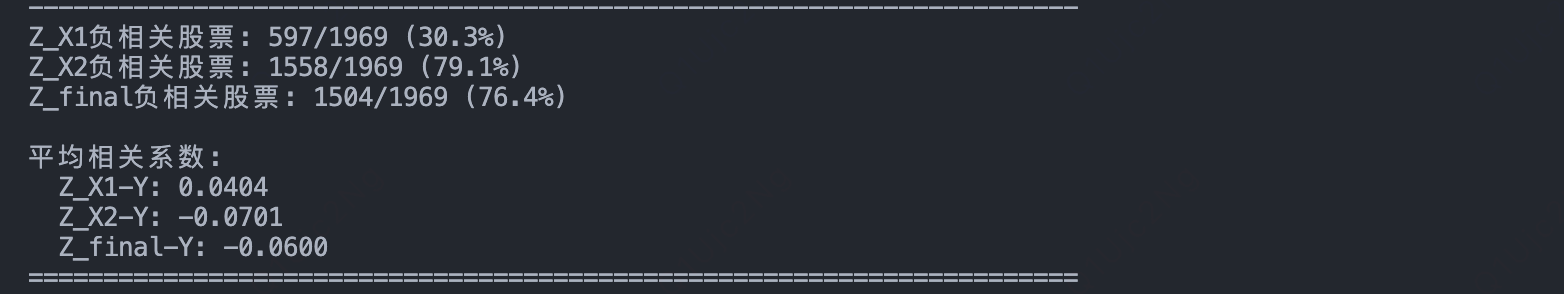

* 在大样本测试下，X1 平均相关性是4%，说明X2是一个动量因子
* X2的IC在-7%，说明X2应该是均值回归的重要锚点

### 共振信号分析
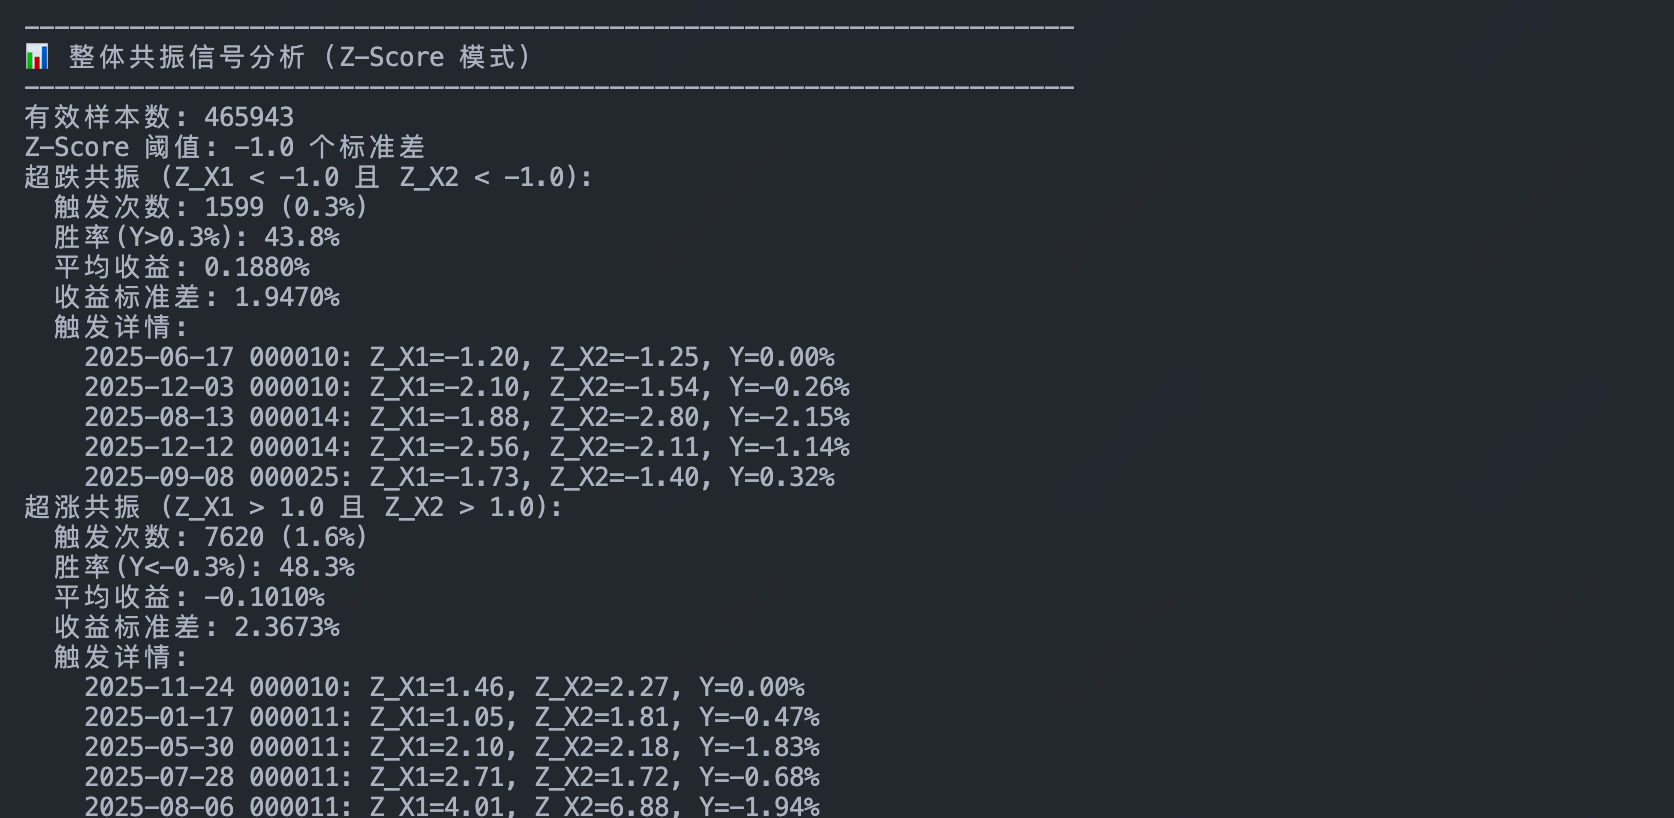


## 7. 接下来可能需要做的工作

##### 目前用了X2,还需要进一步挖掘更多的特征 ？
##### 开始搭模型，用二分类去预测回归的概率？






